# Can We Predict the Future of E-Waste?
## Historical Analysis and 10-Year Forecast (2026–2035)

**Objective:** Use the historical country-year gadget consumption data (2015–2025) to model and forecast e-waste generation for 2026–2035.

### Forecasting strategy
- Keep the original historical observations unchanged.
- Use a **time-aware validation split** rather than a random train/test split.
- Build lag features (`previous-year e-waste`, `two-year-lag e-waste`, and a 3-year rolling mean) so the model can learn temporal persistence.
- Include technology-consumption variables and country as predictors.
- Forecast future predictor variables from their own historical country-level trends; **no future values are hardcoded**.
- Compare Ridge Regression, Gradient Boosting, and Random Forest on the held-out years 2023–2025.
- Select the model with the lowest RMSE, retrain it on all available historical training rows, and recursively forecast 2026–2035.

> **Important:** The dataset contains only 11 annual observations per country. Therefore, the 10-year forecast is an analytical projection, not a guaranteed real-world prediction. Model performance on the 2023–2025 holdout is reported before the future forecast is used.

## 1. Import Libraries

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load and Validate the Dataset

In [ ]:
CSV_PATH = "Global_Tech_Gadget_Consumption.csv"
if not os.path.exists(CSV_PATH) and os.path.exists("/content/Global_Tech_Gadget_Consumption.csv"):
    CSV_PATH = "/content/Global_Tech_Gadget_Consumption.csv"

df = pd.read_csv(CSV_PATH)

required_columns = [
    "Country", "Year", "Smartphone Sales (Millions)",
    "Laptop Shipments (Millions)", "Gaming Console Adoption (%)",
    "Smartwatch Penetration (%)", "Average Consumer Spending on Gadgets ($)",
    "E-Waste Generated (Metric Tons)", "5G Penetration Rate (%)"
]
missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df[required_columns].copy()
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Years: {df['Year'].min()}–{df['Year'].max()}")
display(df.head())

Rows: 110
Countries: 10
Years: 2015–2025


,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
0,Brazil,2015,487.73,95.83,31.67,11.78,2633.96,1681.23,69.94
1,Brazil,2016,275.85,103.08,14.34,21.31,1161.32,1635.14,55.96
2,Brazil,2017,327.88,87.59,6.58,22.57,2113.65,1957.62,11.21
3,Brazil,2018,329.09,142.58,16.16,5.26,2476.34,1348.88,27.93
4,Brazil,2019,349.91,43.47,17.36,21.09,603.13,158.64,36.01


## 3. Data Quality Checks

In [ ]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing_Count"))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Country-Year combinations:", df.duplicated(["Country", "Year"]).sum())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if df[numeric_cols].isna().any().any():
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())
    print("Numeric missing values were median-imputed.")
else:
    print("No missing numeric values found.")

Missing values:


,Missing_Count
Country,0
Year,0
Smartphone Sales (Millions),0
Laptop Shipments (Millions),0
Gaming Console Adoption (%),0
Smartwatch Penetration (%),0
Average Consumer Spending on Gadgets ($),0
E-Waste Generated (Metric Tons),0
5G Penetration Rate (%),0


Duplicate rows: 0
Duplicate Country-Year combinations: 0
No missing numeric values found.


## 4. Historical E-Waste Trend

,Year,E-Waste Generated (Metric Tons)
0,2015,8817.21
1,2016,10285.50
2,2017,11065.61
3,2018,13025.96
4,2019,11873.94
5,2020,9621.77
6,2021,10763.37
7,2022,7647.33
8,2023,9428.00
9,2024,11228.14


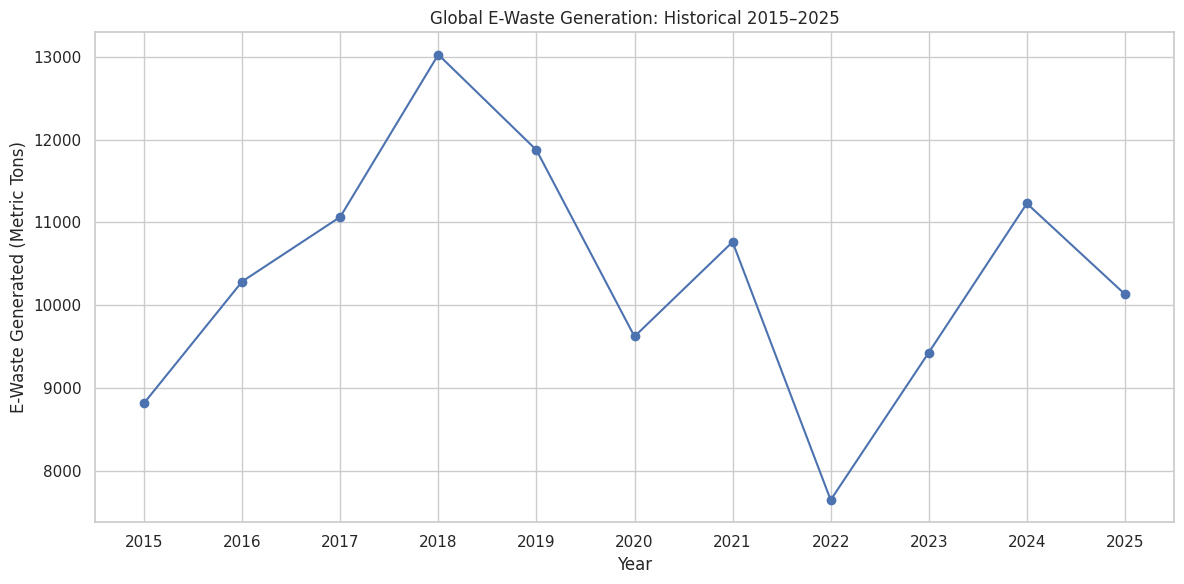

2015 → 2025 endpoint CAGR: 1.40%


In [ ]:
yearly_waste = (
    df.groupby("Year", as_index=False)["E-Waste Generated (Metric Tons)"]
      .sum()
      .sort_values("Year")
)

display(yearly_waste)

plt.figure(figsize=(12, 6))
plt.plot(yearly_waste["Year"], yearly_waste["E-Waste Generated (Metric Tons)"], marker="o")
plt.title("Global E-Waste Generation: Historical 2015–2025")
plt.xlabel("Year")
plt.ylabel("E-Waste Generated (Metric Tons)")
plt.xticks(yearly_waste["Year"])
plt.tight_layout()
plt.show()

first_value = yearly_waste.iloc[0]["E-Waste Generated (Metric Tons)"]
last_value = yearly_waste.iloc[-1]["E-Waste Generated (Metric Tons)"]
endpoint_cagr = (last_value / first_value) ** (1 / (len(yearly_waste) - 1)) - 1
print(f"2015 → 2025 endpoint CAGR: {endpoint_cagr * 100:.2f}%")

## 5. Relationship Between Technology Variables and E-Waste

Correlation is used only as an exploratory diagnostic. It is **not** treated as proof of causation.

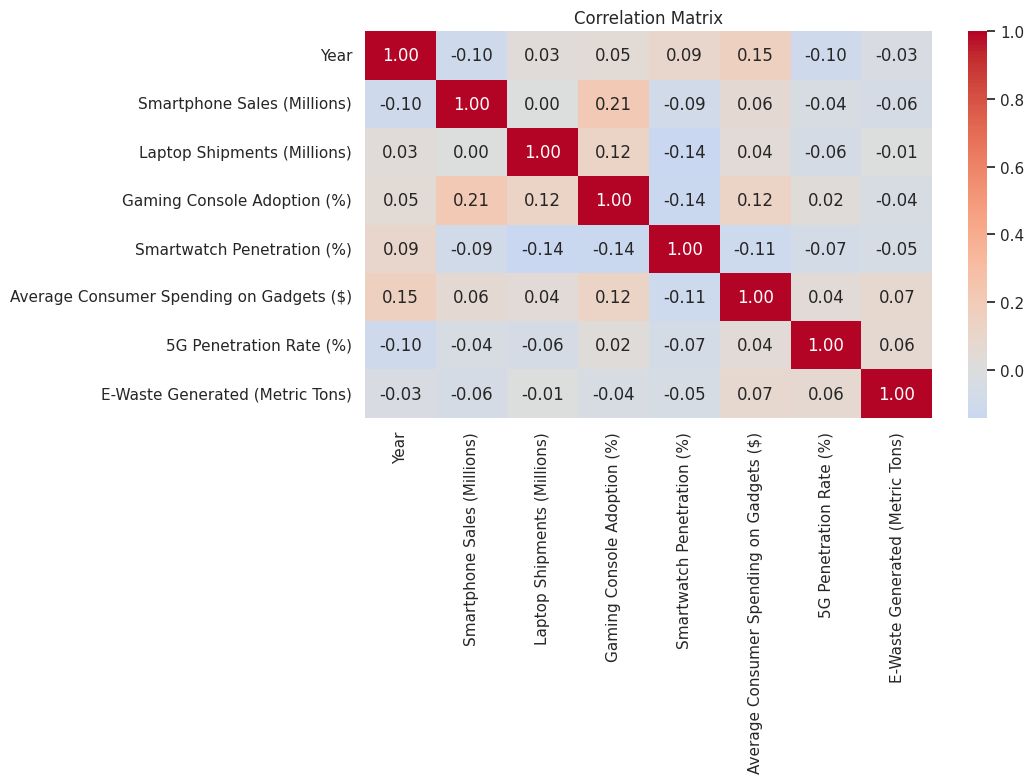

In [ ]:
corr_cols = [
    "Year", "Smartphone Sales (Millions)", "Laptop Shipments (Millions)",
    "Gaming Console Adoption (%)", "Smartwatch Penetration (%)",
    "Average Consumer Spending on Gadgets ($)", "5G Penetration Rate (%)",
    "E-Waste Generated (Metric Tons)"
]
plt.figure(figsize=(11, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Create Time-Series Features

For each country, the model uses the previous e-waste values so that forecasting is genuinely sequential. The first two years cannot have a two-year lag and are therefore excluded from supervised training.

In [ ]:
target = "E-Waste Generated (Metric Tons)"
exogenous_cols = [
    "Smartphone Sales (Millions)",
    "Laptop Shipments (Millions)",
    "Gaming Console Adoption (%)",
    "Smartwatch Penetration (%)",
    "Average Consumer Spending on Gadgets ($)",
    "5G Penetration Rate (%)"
]

model_df = df.copy()
model_df["E_Waste_Lag_1"] = model_df.groupby("Country")[target].shift(1)
model_df["E_Waste_Lag_2"] = model_df.groupby("Country")[target].shift(2)
model_df["E_Waste_Rolling_3"] = (
    model_df.groupby("Country")[target]
             .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

feature_cols = [
    "Year", "Country", "E_Waste_Lag_1", "E_Waste_Lag_2", "E_Waste_Rolling_3"
] + exogenous_cols

supervised = model_df.dropna(subset=["E_Waste_Lag_1", "E_Waste_Lag_2"]).copy()
print(f"Supervised observations: {len(supervised)}")
display(supervised[feature_cols + [target]].head())

Supervised observations: 90


,Year,Country,E_Waste_Lag_1,E_Waste_Lag_2,E_Waste_Rolling_3,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),5G Penetration Rate (%),E-Waste Generated (Metric Tons)
2,2017,Brazil,1635.14,1681.23,1658.185000,327.88,87.59,6.58,22.57,2113.65,11.21,1957.62
3,2018,Brazil,1957.62,1635.14,1757.996667,329.09,142.58,16.16,5.26,2476.34,27.93,1348.88
4,2019,Brazil,1348.88,1957.62,1647.213333,349.91,43.47,17.36,21.09,603.13,36.01,158.64
5,2020,Brazil,158.64,1348.88,1155.046667,296.16,56.45,39.22,16.09,220.09,56.91,1913.13
6,2021,Brazil,1913.13,158.64,1140.216667,397.00,125.19,12.59,22.75,1845.58,67.93,1250.45


## 7. Time-Aware Train/Test Split

The model is trained only on **2015–2022 history** and evaluated on **2023–2025**. This avoids random shuffling, which would leak future information into training.

In [ ]:
train = supervised[supervised["Year"] <= 2022].copy()
test = supervised[supervised["Year"] >= 2023].copy()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]

print(f"Training rows: {len(train)} | Test rows: {len(test)}")
print(f"Training period: {train['Year'].min()}–{train['Year'].max()}")
print(f"Test period: {test['Year'].min()}–{test['Year'].max()}")

Training rows: 60 | Test rows: 30
Training period: 2017–2022
Test period: 2023–2025


## 8. Compare Forecasting Models

Three models are evaluated:
1. **Ridge Regression** — regularized linear baseline.
2. **Gradient Boosting** — nonlinear ensemble model.
3. **Random Forest** — nonlinear tree ensemble, useful when relationships are not purely linear.

The model with the lowest **RMSE** on the future holdout is selected.

In [ ]:
numeric_features = [c for c in feature_cols if c != "Country"]
categorical_features = ["Country"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

models = {
    "Ridge": Ridge(alpha=10.0),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE, n_estimators=150,
        learning_rate=0.03, max_depth=2, loss="huber"
    ),
    "Random Forest": RandomForestRegressor(
        random_state=RANDOM_STATE, n_estimators=500,
        min_samples_leaf=3, max_features=0.7, n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = np.maximum(0, pipe.predict(X_test))
    fitted_models[name] = pipe
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

model_results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(model_results.style.format({"MAE": "{:,.1f}", "RMSE": "{:,.1f}", "R2": "{:.3f}"}))

best_model_name = model_results.loc[0, "Model"]
print(f"Selected model based on lowest holdout RMSE: {best_model_name}")

,Model,MAE,RMSE,R2
0,Random Forest,459.9,554.6,-0.085
1,Gradient Boosting,473.7,561.0,-0.110
2,Ridge,563.1,705.0,-0.752


Selected model based on lowest holdout RMSE: Random Forest


## 9. Holdout Diagnostic: Actual vs Predicted E-Waste

,Country,Year,E-Waste Generated (Metric Tons),Predicted
8,Brazil,2023,479.54,962.322993
19,Canada,2023,1368.87,1096.091394
30,China,2023,414.10,1208.968196
41,France,2023,734.12,920.823272
52,Germany,2023,589.30,1068.958863
63,India,2023,1962.59,862.303426
74,Japan,2023,1111.27,1035.602114
85,South Korea,2023,1007.50,989.378893
96,UK,2023,278.39,1035.798714
107,USA,2023,1482.32,1046.176912


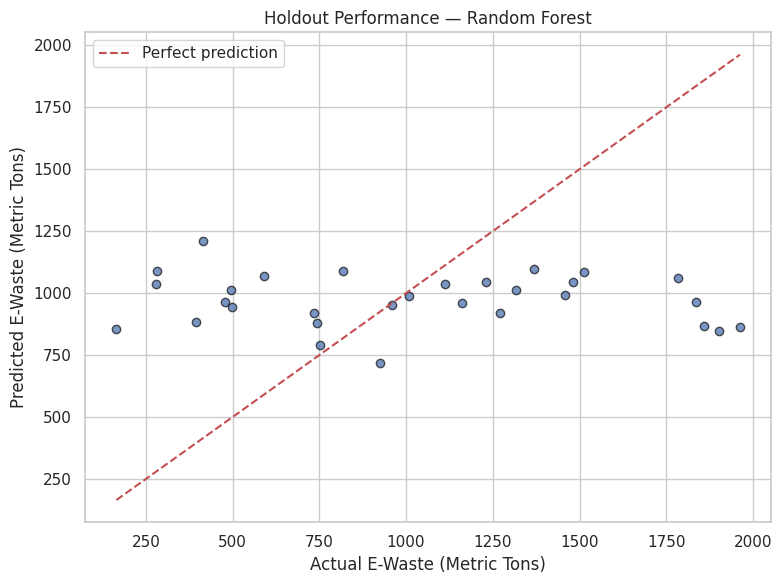

Holdout MAE : 459.9 metric tons
Holdout RMSE: 554.6 metric tons
Holdout R²  : -0.085


In [ ]:
best_pipe = fitted_models[best_model_name]
test_pred = np.maximum(0, best_pipe.predict(X_test))

test_plot = test[["Country", "Year", target]].copy()
test_plot["Predicted"] = test_pred

display(test_plot.sort_values(["Year", "Country"]).head(30))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.75, edgecolor="k")
lo = min(y_test.min(), test_pred.min())
hi = max(y_test.max(), test_pred.max())
plt.plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")
plt.xlabel("Actual E-Waste (Metric Tons)")
plt.ylabel("Predicted E-Waste (Metric Tons)")
plt.title(f"Holdout Performance — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Holdout MAE : {mean_absolute_error(y_test, test_pred):,.1f} metric tons")
print(f"Holdout RMSE: {mean_squared_error(y_test, test_pred) ** 0.5:,.1f} metric tons")
print(f"Holdout R²  : {r2_score(y_test, test_pred):.3f}")

## 10. Forecast Future Technology Variables (2026–2035)

A future ML prediction needs future predictor values. Since the dataset ends in 2025, those values are estimated **for each country from its own 2015–2025 historical trend** using linear regression. This is a transparent assumption and avoids hardcoding future gadget-consumption values.

In [ ]:
future_year_values = np.arange(2026, 2036)
future_exogenous = []

for country, g in df.groupby("Country"):
    g = g.sort_values("Year")
    future_part = pd.DataFrame({"Country": country, "Year": future_year_values})
    for col in exogenous_cols:
        trend_model = LinearRegression()
        trend_model.fit(g[["Year"]], g[col])
        values = trend_model.predict(future_part[["Year"]])
        if "(%)" in col or "Penetration" in col or "Adoption" in col:
            values = np.clip(values, 0, 100)
        else:
            values = np.clip(values, 0, None)
        future_part[col] = values
    future_exogenous.append(future_part)

future_exogenous = pd.concat(future_exogenous, ignore_index=True)
display(future_exogenous.head(10))

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),5G Penetration Rate (%)
0,Brazil,2026,195.719636,84.777818,21.665636,14.873636,1488.036545,32.862000
1,Brazil,2027,179.168364,83.507909,21.955818,14.680909,1453.634000,31.342182
2,Brazil,2028,162.617091,82.238000,22.246000,14.488182,1419.231455,29.822364
3,Brazil,2029,146.065818,80.968091,22.536182,14.295455,1384.828909,28.302545
4,Brazil,2030,129.514545,79.698182,22.826364,14.102727,1350.426364,26.782727
5,Brazil,2031,112.963273,78.428273,23.116545,13.910000,1316.023818,25.262909
6,Brazil,2032,96.412000,77.158364,23.406727,13.717273,1281.621273,23.743091
7,Brazil,2033,79.860727,75.888455,23.696909,13.524545,1247.218727,22.223273
8,Brazil,2034,63.309455,74.618545,23.987091,13.331818,1212.816182,20.703455
9,Brazil,2035,46.758182,73.348636,24.277273,13.139091,1178.413636,19.183636


## 11. Recursive E-Waste Forecast: 2026–2035

The selected model is retrained on all historical supervised observations. Forecasting then proceeds one year at a time. Each predicted year becomes the lagged input for the next year, which prevents the future from using unavailable actual e-waste values.

In [ ]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])
final_model.fit(supervised[feature_cols], supervised[target])

future_predictions = []

for country, g in df.groupby("Country"):
    g = g.sort_values("Year")
    history_ewaste = list(g[target].astype(float).values)
    country_future = future_exogenous[future_exogenous["Country"] == country].sort_values("Year")

    for _, future_row in country_future.iterrows():
        row = {
            "Year": int(future_row["Year"]),
            "Country": country,
            "E_Waste_Lag_1": history_ewaste[-1],
            "E_Waste_Lag_2": history_ewaste[-2],
            "E_Waste_Rolling_3": float(np.mean(history_ewaste[-3:]))
        }
        for col in exogenous_cols:
            row[col] = future_row[col]

        prediction = float(final_model.predict(pd.DataFrame([row])[feature_cols])[0])
        prediction = max(0.0, prediction)
        history_ewaste.append(prediction)
        future_predictions.append({
            "Country": country,
            "Year": int(future_row["Year"]),
            "Forecast_E_Waste_Metric_Tons": prediction
        })

country_forecast_df = pd.DataFrame(future_predictions)

global_forecast = (
    country_forecast_df.groupby("Year", as_index=False)["Forecast_E_Waste_Metric_Tons"]
                       .sum()
)

display(global_forecast)
print("Forecast generated without hardcoded future e-waste values.")

,Year,Forecast_E_Waste_Metric_Tons
0,2026,9500.931462
1,2027,9735.218537
2,2028,10098.787372
3,2029,10074.051230
4,2030,10099.424820
5,2031,10186.590922
6,2032,10370.177477
7,2033,10503.053948
8,2034,10557.934372
9,2035,10633.972928


Forecast generated without hardcoded future e-waste values.


## 12. Final Global Forecast: Historical + 2026–2035

This is the main result for the project. The forecast is produced by the selected ML model using historical e-waste lags, country information, year, and technology-consumption variables.

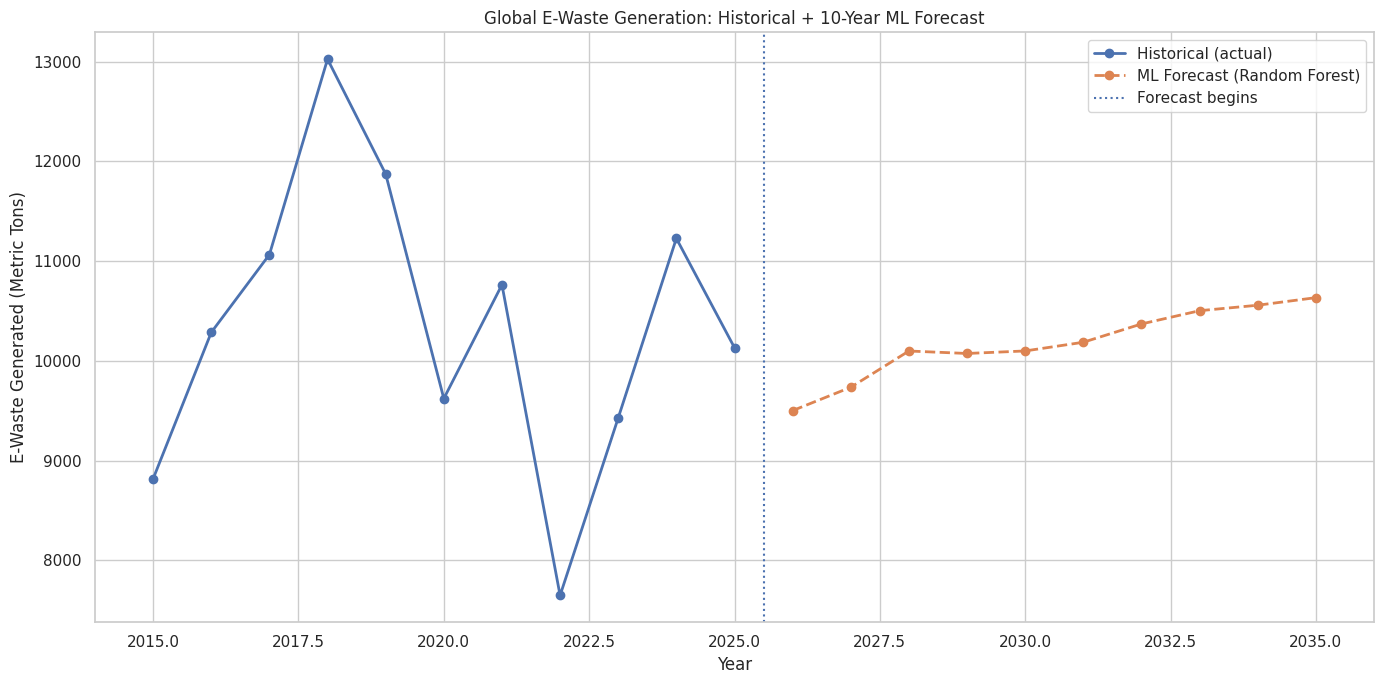

2025 actual: 10,132 metric tons
2030 forecast: 10,099 metric tons
2035 forecast: 10,634 metric tons
Change from 2025 to 2035: +5.0%


In [ ]:
historical_plot = yearly_waste.rename(columns={target: "E_Waste_Metric_Tons"})

plt.figure(figsize=(14, 7))
plt.plot(
    historical_plot["Year"], historical_plot["E_Waste_Metric_Tons"],
    marker="o", linewidth=2, label="Historical (actual)"
)
plt.plot(
    global_forecast["Year"], global_forecast["Forecast_E_Waste_Metric_Tons"],
    marker="o", linestyle="--", linewidth=2, label=f"ML Forecast ({best_model_name})"
)
plt.axvline(2025.5, linestyle=":", linewidth=1.5, label="Forecast begins")
plt.title("Global E-Waste Generation: Historical + 10-Year ML Forecast")
plt.xlabel("Year")
plt.ylabel("E-Waste Generated (Metric Tons)")
plt.legend()
plt.tight_layout()
plt.show()

forecast_2030 = float(global_forecast.loc[global_forecast["Year"] == 2030, "Forecast_E_Waste_Metric_Tons"].iloc[0])
forecast_2035 = float(global_forecast.loc[global_forecast["Year"] == 2035, "Forecast_E_Waste_Metric_Tons"].iloc[0])
last_actual = float(yearly_waste.iloc[-1][target])
change_to_2035 = (forecast_2035 / last_actual - 1) * 100

print(f"2025 actual: {last_actual:,.0f} metric tons")
print(f"2030 forecast: {forecast_2030:,.0f} metric tons")
print(f"2035 forecast: {forecast_2035:,.0f} metric tons")
print(f"Change from 2025 to 2035: {change_to_2035:+.1f}%")

## 13. Forecast Interpretation and Limitations

- A rising forecast is **not forced**. It is generated recursively from the selected model and forecasted technology variables.
- If the forecast rises, the model is projecting higher e-waste under the assumed continuation of historical technology trends.
- If the forecast contains short-term dips, that does not mean e-waste disappears; it reflects the model's learned country-level dynamics.
- The dataset has only 11 years per country, so long-horizon uncertainty is substantial.
- Future technology variables are themselves forecasts, so uncertainty compounds beyond 2025.
- The dataset should therefore be described as suitable for **academic predictive analysis and scenario planning**, not as an official environmental projection.
- For a production/research-grade forecast, the next improvement would be a longer historical series and externally sourced future assumptions for device sales, population, device lifetime, collection rates, and recycling rates.

## 14. Dashboard-Ready Export

The following files are exported so a dashboard can be built later without changing the forecasting logic.

In [ ]:
os.makedirs("dashboard_data", exist_ok=True)

df.to_csv("dashboard_data/cleaned_gadget_consumption.csv", index=False)
yearly_waste.to_csv("dashboard_data/global_ewaste_historical.csv", index=False)
global_forecast.to_csv("dashboard_data/global_ewaste_forecast.csv", index=False)
country_forecast_df.to_csv("dashboard_data/country_ewaste_forecast.csv", index=False)
future_exogenous.to_csv("dashboard_data/future_exogenous_forecasts_2026_2035.csv", index=False)
model_results.to_csv("dashboard_data/model_comparison.csv", index=False)

authenticity_note = {
    "historical_period": "2015-2025",
    "forecast_period": "2026-2035",
    "target": target,
    "selected_model": best_model_name,
    "selection_metric": "RMSE on time-based 2023-2025 holdout",
    "holdout_mae": round(float(mean_absolute_error(y_test, test_pred)), 2),
    "holdout_rmse": round(float(mean_squared_error(y_test, test_pred) ** 0.5), 2),
    "holdout_r2": round(float(r2_score(y_test, test_pred)), 4),
    "forecast_2030_metric_tons": round(forecast_2030, 2),
    "forecast_2035_metric_tons": round(forecast_2035, 2),
    "forecast_method": "Recursive country-level ML forecast with lagged e-waste and forecasted technology variables",
    "future_features_hardcoded": False
}
with open("dashboard_data/forecast_metadata.json", "w") as f:
    json.dump(authenticity_note, f, indent=2)

print("Dashboard-ready files created:")
for fname in sorted(os.listdir("dashboard_data")):
    print(" -", fname)

Dashboard-ready files created:
 - cleaned_gadget_consumption.csv
 - country_ewaste_forecast.csv
 - forecast_metadata.json
 - future_exogenous_forecasts_2026_2035.csv
 - global_ewaste_forecast.csv
 - global_ewaste_historical.csv
 - model_comparison.csv


## Final Project Statement

> **Can we predict the future of e-waste?** Yes, to a limited analytical extent. Using historical e-waste, technology-consumption indicators, country effects, and temporal lag features, a time-aware machine-learning model can generate a 2026–2035 forecast. The forecast should be interpreted as a data-driven projection under continuation of historical patterns, not as a guaranteed future value.